# Seasonal Agriculture Performance Analysis

**Domain:** Agriculture

**Project Theme:** Seasonal Agriculture Performance

**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn, SciPy


**VOIS AICTE Data Analytics Internship — Batch 2026-2027**

Siddhi Santosh Jagtap — Army Institute of Technology, Pune

---

### Project Goal
Investigate how agricultural performance varies across seasons and identify meaningful patterns, trends, relationships and differences in the available data.



## 1. Problem Statement

Agricultural activities are influenced by seasonal variations in environmental conditions, farming practices, resource availability and market conditions. As a result, agricultural performance may differ from one season to another.

The objective of this project is to analyze the given agricultural dataset and investigate seasonal differences in agricultural performance by identifying meaningful patterns, trends, relationships and variations within the available data.

Students should independently explore the dataset, formulate relevant analytical questions, select suitable analytical techniques and communicate findings based on evidence from the data.

## 2. Project Objectives

- Explore and understand the dataset.
- Clean and prepare the data for analysis.
- Examine how agricultural performance varies across seasons.
- Perform descriptive and statistical analysis.
- Investigate relationships among relevant variables.
- Compare agricultural performance across seasons and other meaningful groups.
- Use appropriate univariate, bivariate and multivariate visualizations.
- Identify significant findings from the data.
- Develop evidence-based insights and recommendations.

## 3. Dataset

The dataset contains farm-level agricultural records covering different seasons, locations, crops, environmental conditions, farming practices, production, costs, revenue, profit and resource usage.

**Dataset file:** `seasonal_agriculture_performance_dataset.csv`

The notebook is designed so that the CSV should be placed in a `data/` folder alongside this notebook (see the path used in the load-data cell below).

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 150)

sns.set_style('whitegrid')
plt.rcParams.update({
    'font.size': 12, 'axes.edgecolor': '#444444', 'axes.labelcolor': '#222222',
    'text.color': '#222222', 'xtick.color': '#333333', 'ytick.color': '#333333',
    'axes.spines.top': False, 'axes.spines.right': False,
    'figure.facecolor': 'white', 'axes.facecolor': 'white'
})

SEASON_ORDER = ['Kharif', 'Rabi', 'Zaid']
PALETTE = {'Kharif': '#2E7D32', 'Rabi': '#F9A825', 'Zaid': '#C62828'}

import os
os.makedirs('../reports/figures', exist_ok=True)
print('Libraries loaded.')

Libraries loaded.


In [2]:
# Load dataset
df = pd.read_csv('../data/seasonal_agriculture_performance_dataset.csv')
df.shape

(4000, 28)

## 4. Initial Dataset Exploration

In [3]:
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   str    
 1   State                          4000 non-null   str    
 2   District                       4000 non-null   str    
 3   Crop                           4000 non-null   str    
 4   Season                         4000 non-null   str    
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   float64
 13 

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,3952.0,601.152657,288.925025,80.000,370.200,582.0000,834.95000,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,3960.0,26.508232,6.712484,8.000,21.700,26.4000,31.30000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


In [6]:
print("Missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print()
print("Duplicate rows:", df.duplicated().sum())

Missing values per column:
Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64

Duplicate rows: 0


In [7]:
for col in ['Season', 'Crop', 'State', 'Irrigation_Method']:
    print(f"--- {col} ({df[col].nunique()} unique) ---")
    print(df[col].value_counts())
    print()

--- Season (3 unique) ---
Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

--- Crop (8 unique) ---
Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64

--- State (8 unique) ---
State
Andhra Pradesh    529
Telangana         516
Maharashtra       512
Madhya Pradesh    497
Karnataka         489
Gujarat           488
Tamil Nadu        485
Punjab            484
Name: count, dtype: int64

--- Irrigation_Method (4 unique) ---
Irrigation_Method
Flood        1310
Rainfed      1041
Drip          915
Sprinkler     734
Name: count, dtype: int64



**Observation:** `State`–`District` pairings in this dataset do not correspond to real Indian geography (the same district name appears under multiple unrelated states). This confirms the dataset is synthetically generated, so `District` is treated only as a category label — not a validated location — in this analysis. `State` is used for any regional comparison instead.

Also, `Yield_Tonnes_Ha` values above ~20 t/ha are almost entirely Sugarcane records, which is agronomically expected (sugarcane yields far more tonnes/hectare than grain crops). This is a real crop-scale difference, not a data error — so yield is compared **per crop**, never pooled across crops.

## 5. Data Cleaning and Preparation

Only three columns have missing values: `Rainfall_mm`, `Soil_Moisture_pct` and `Yield_Tonnes_Ha` (all under 1.2% of rows). Missing environmental readings are filled with the **median for that season** (rainfall/soil moisture are season-driven), and missing yield is filled with the **median for that crop** (since yield scale differs sharply by crop).

In [8]:
df['Rainfall_mm'] = df.groupby('Season')['Rainfall_mm'].transform(lambda x: x.fillna(x.median()))
df['Soil_Moisture_pct'] = df.groupby('Season')['Soil_Moisture_pct'].transform(lambda x: x.fillna(x.median()))
df['Yield_Tonnes_Ha'] = df.groupby('Crop')['Yield_Tonnes_Ha'].transform(lambda x: x.fillna(x.median()))

print("Remaining missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Remaining missing values: 0
Duplicate rows: 0


In [9]:
# A crop-normalised yield column (z-score within each crop) lets us compare
# seasonal yield differences without the comparison being dominated by crop-scale
# differences (e.g. Sugarcane vs Pulses).
df['Yield_Z_Within_Crop'] = df.groupby('Crop')['Yield_Tonnes_Ha'].transform(lambda x: (x - x.mean()) / x.std())
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct,Yield_Z_Within_Crop
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3,0.383602
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9,-1.962579
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7,-0.940922
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6,-0.525457
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3,-0.412381


## 6. Univariate Analysis

Examining one variable at a time: the distribution of records by season, and the overall spread of yield and profit.

/tmp/ipykernel_499/3926488177.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Season', order=SEASON_ORDER, palette=PALETTE)


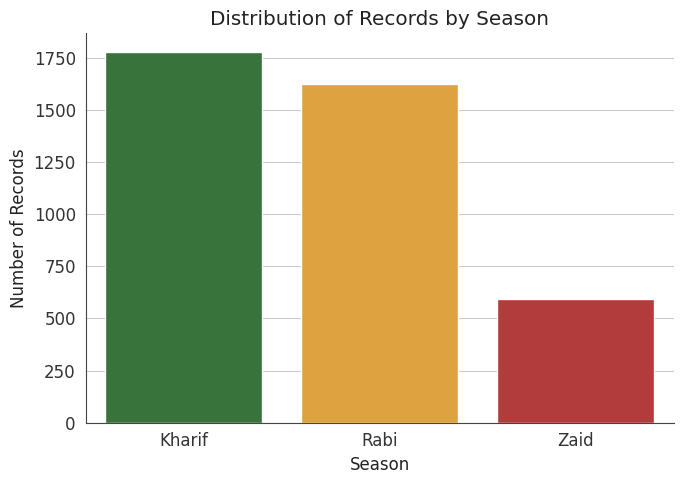

In [10]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='Season', order=SEASON_ORDER, palette=PALETTE)
plt.title('Distribution of Records by Season')
plt.xlabel('Season')
plt.ylabel('Number of Records')
plt.tight_layout()
plt.savefig('../reports/figures/01_records_by_season.png', dpi=150, bbox_inches='tight')
plt.show()

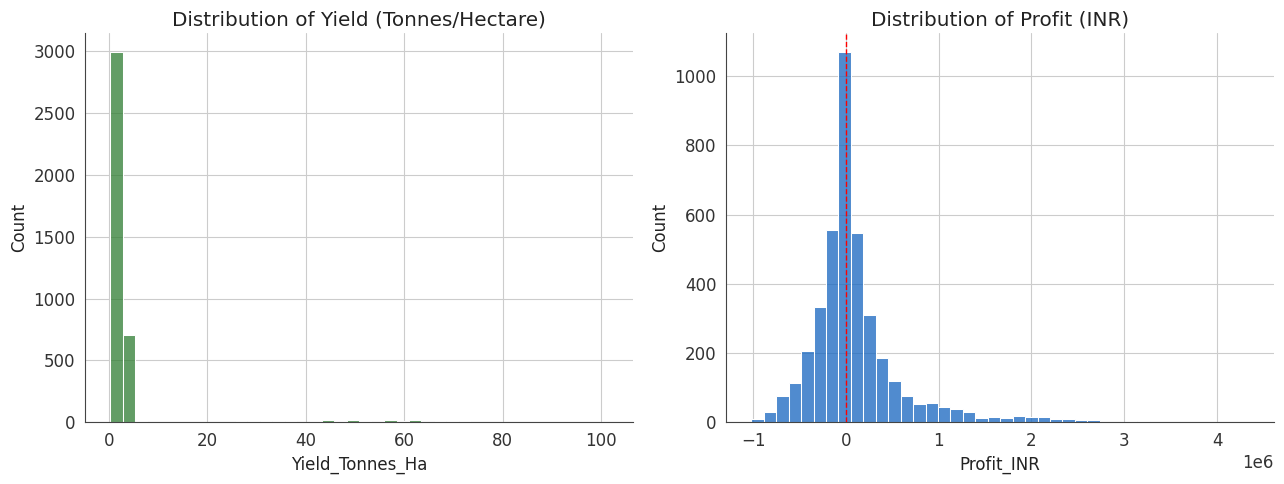

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.histplot(df['Yield_Tonnes_Ha'], bins=40, ax=axes[0], color='#2E7D32')
axes[0].set_title('Distribution of Yield (Tonnes/Hectare)')
sns.histplot(df['Profit_INR'], bins=40, ax=axes[1], color='#1565C0')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_title('Distribution of Profit (INR)')
plt.tight_layout()
plt.savefig('../reports/figures/02_yield_profit_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
neg_profit_pct = (df['Profit_INR'] < 0).mean() * 100
print(f"Farms operating at a loss: {(df['Profit_INR'] < 0).sum()} of {len(df)} ({neg_profit_pct:.1f}%)")

Farms operating at a loss: 1966 of 4000 (49.1%)


## 7. Seasonal Analysis — Yield, Environment, Resources and Economics

### 7.1 Yield by Crop and Season

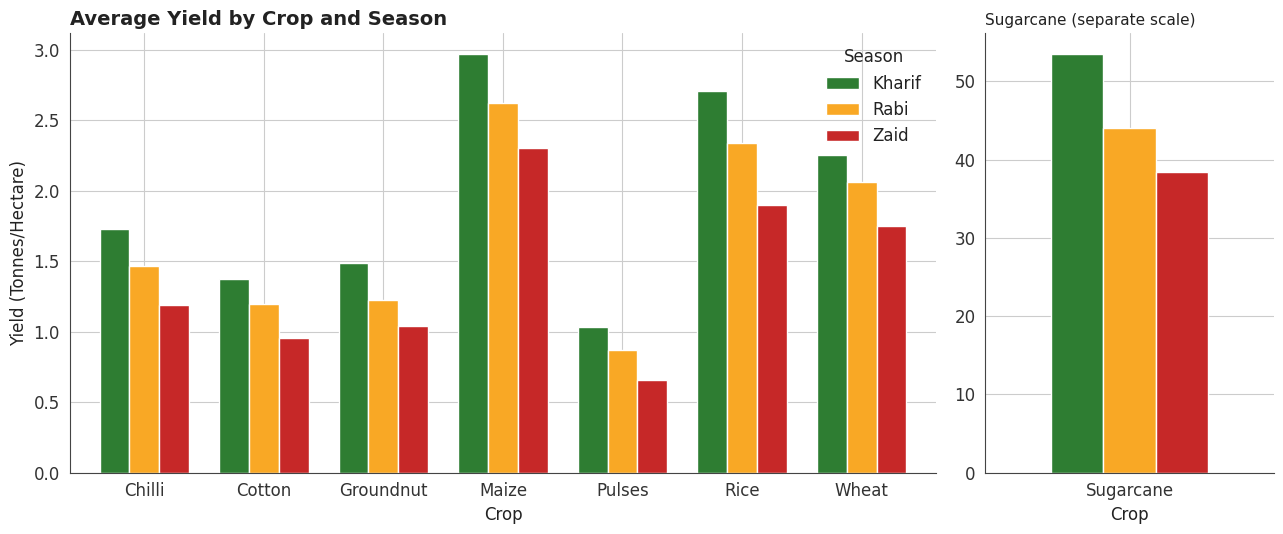

Season     Kharif   Rabi   Zaid
Crop                           
Chilli       1.73   1.46   1.19
Cotton       1.37   1.19   0.95
Groundnut    1.48   1.23   1.04
Maize        2.97   2.62   2.30
Pulses       1.04   0.87   0.66
Rice         2.71   2.34   1.90
Sugarcane   53.46  44.00  38.42
Wheat        2.26   2.06   1.75


In [13]:
pivot = df.groupby(['Crop', 'Season'])['Yield_Tonnes_Ha'].mean().unstack()[SEASON_ORDER]
pivot_no_sugarcane = pivot.drop('Sugarcane')

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), gridspec_kw={'width_ratios': [3, 1]})
pivot_no_sugarcane.plot(kind='bar', ax=axes[0], color=[PALETTE[s] for s in SEASON_ORDER], width=0.75)
axes[0].set_title('Average Yield by Crop and Season', fontsize=14, fontweight='bold', loc='left')
axes[0].set_ylabel('Yield (Tonnes/Hectare)')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Season', frameon=False)

pivot.loc[['Sugarcane']].plot(kind='bar', ax=axes[1], color=[PALETTE[s] for s in SEASON_ORDER], width=0.6, legend=False)
axes[1].set_title('Sugarcane (separate scale)', fontsize=11, loc='left')
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig('../reports/figures/03_yield_by_crop_season.png', dpi=150, bbox_inches='tight')
plt.show()

print(pivot.round(2))

**Finding:** Every crop yields highest in Kharif and lowest in Zaid, with Rabi in between — the ranking is completely consistent across all 8 crops.

### 7.2 Environmental Conditions by Season

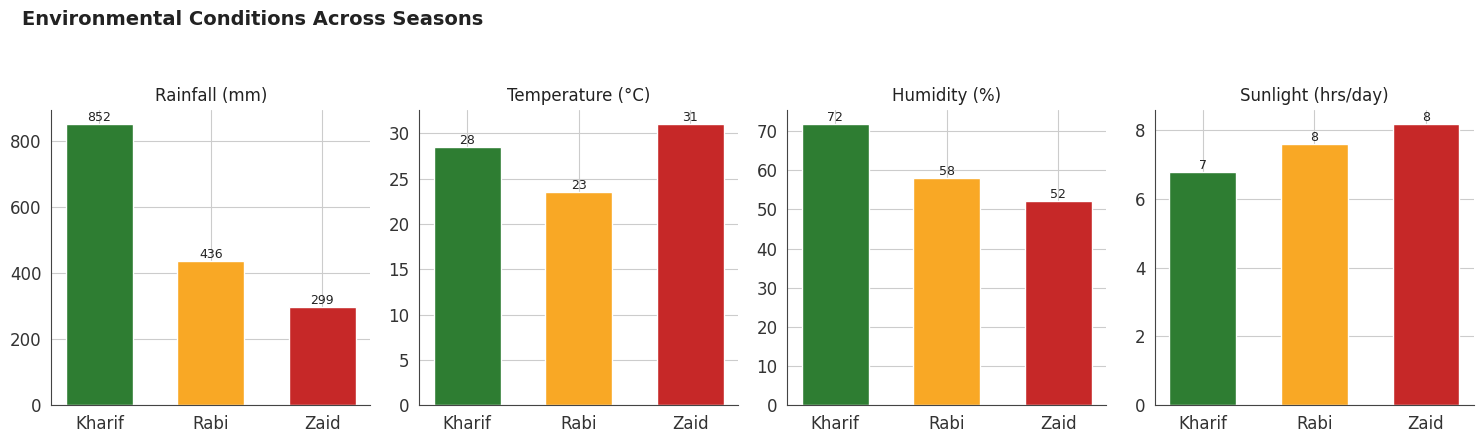

In [14]:
env_vars = [('Rainfall_mm', 'Rainfall (mm)'), ('Avg_Temperature_C', 'Temperature (°C)'),
            ('Humidity_pct', 'Humidity (%)'), ('Sunlight_Hours_Day', 'Sunlight (hrs/day)')]

fig, axes = plt.subplots(1, 4, figsize=(15, 4.5))
for ax, (col, label) in zip(axes, env_vars):
    means = df.groupby('Season')[col].mean().reindex(SEASON_ORDER)
    ax.bar(means.index, means.values, color=[PALETTE[s] for s in SEASON_ORDER], width=0.6)
    ax.set_title(label, fontsize=12)
    for i, v in enumerate(means.values):
        ax.text(i, v, f'{v:.0f}', ha='center', va='bottom', fontsize=9)
fig.suptitle('Environmental Conditions Across Seasons', fontsize=14, fontweight='bold', x=0.02, ha='left')
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig('../reports/figures/04_environmental_by_season.png', dpi=150, bbox_inches='tight')
plt.show()

**Finding:** Kharif is the wettest and most humid season; Zaid is the hottest and driest, which lines up with the real Indian monsoon (Kharif), winter (Rabi) and summer (Zaid) cropping calendar.

### 7.3 Resource Usage by Season

In [15]:
resource_vars = ['Fertilizer_kg_ha', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha',
                  'Pesticide_Litre_ha', 'Water_Used_m3']
res_by_season = df.groupby('Season')[resource_vars].mean().reindex(SEASON_ORDER).round(2)
res_by_season

,Fertilizer_kg_ha,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Pesticide_Litre_ha,Water_Used_m3
Season,,,,,,
Kharif,187.08,120.02,58.10,105.30,5.08,6102.20
Rabi,185.41,120.40,57.31,103.93,5.02,5846.99
Zaid,184.64,120.53,58.13,105.42,5.17,6419.89


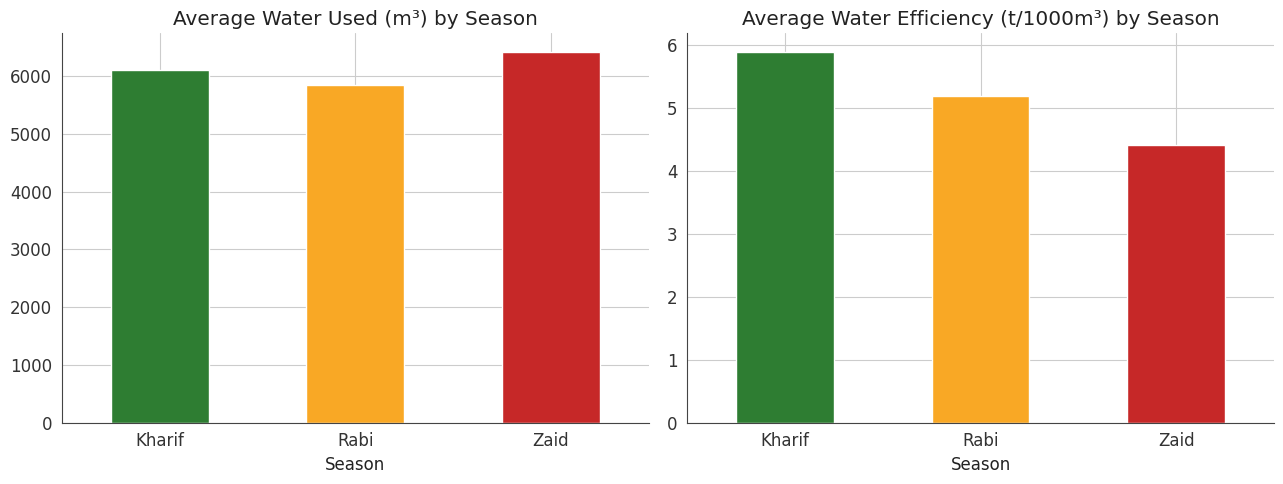

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
df.groupby('Season')['Water_Used_m3'].mean().reindex(SEASON_ORDER).plot(
    kind='bar', ax=axes[0], color=[PALETTE[s] for s in SEASON_ORDER])
axes[0].set_title('Average Water Used (m³) by Season')
axes[0].tick_params(axis='x', rotation=0)

df.groupby('Season')['Water_Efficiency_t_per_1000m3'].mean().reindex(SEASON_ORDER).plot(
    kind='bar', ax=axes[1], color=[PALETTE[s] for s in SEASON_ORDER])
axes[1].set_title('Average Water Efficiency (t/1000m³) by Season')
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig('../reports/figures/05_resource_use_by_season.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.4 Economic Performance by Season

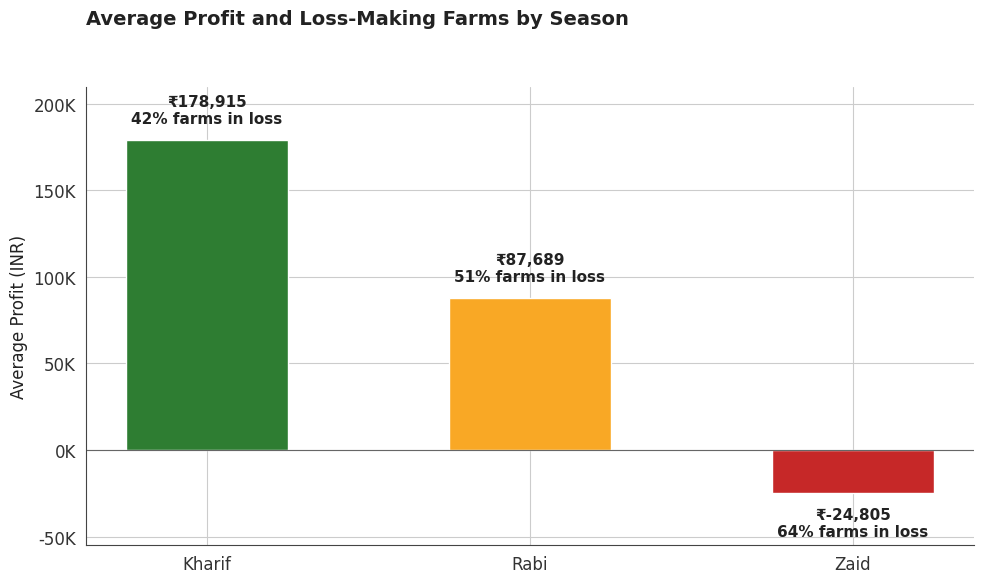

,avg_profit,pct_negative_profit
Season,,
Kharif,178914.65,42.21
Rabi,87689.47,51.14
Zaid,-24804.82,64.48


In [17]:
seasonal_econ = df.groupby('Season').agg(
    avg_profit=('Profit_INR', 'mean'),
    pct_negative_profit=('Profit_INR', lambda x: (x < 0).mean() * 100)
).reindex(SEASON_ORDER)

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(seasonal_econ.index, seasonal_econ['avg_profit'], color=[PALETTE[s] for s in SEASON_ORDER], width=0.5)
ax.axhline(0, color='#666666', linewidth=0.8)
ax.set_ylabel('Average Profit (INR)')
ax.set_title('Average Profit and Loss-Making Farms by Season', fontsize=14, fontweight='bold', loc='left', pad=45)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x/1000:,.0f}K'))
ax.set_ylim(-55000, 210000)
for i, (idx, row) in enumerate(seasonal_econ.iterrows()):
    y = row['avg_profit']
    va = 'bottom' if y >= 0 else 'top'
    offset = 8000 if y >= 0 else -8000
    ax.text(i, y + offset, f"₹{y:,.0f}\n{row['pct_negative_profit']:.0f}% farms in loss",
            ha='center', va=va, fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/06_profit_by_season.png', dpi=150, bbox_inches='tight')
plt.show()

seasonal_econ.round(2)

**Finding:** Kharif is by far the most profitable season on average, while Zaid farms make a loss on average, and the proportion of loss-making farms rises steadily from Kharif (42%) to Rabi (51%) to Zaid (64%).

### 7.5 Irrigation Method vs Water Efficiency and Yield

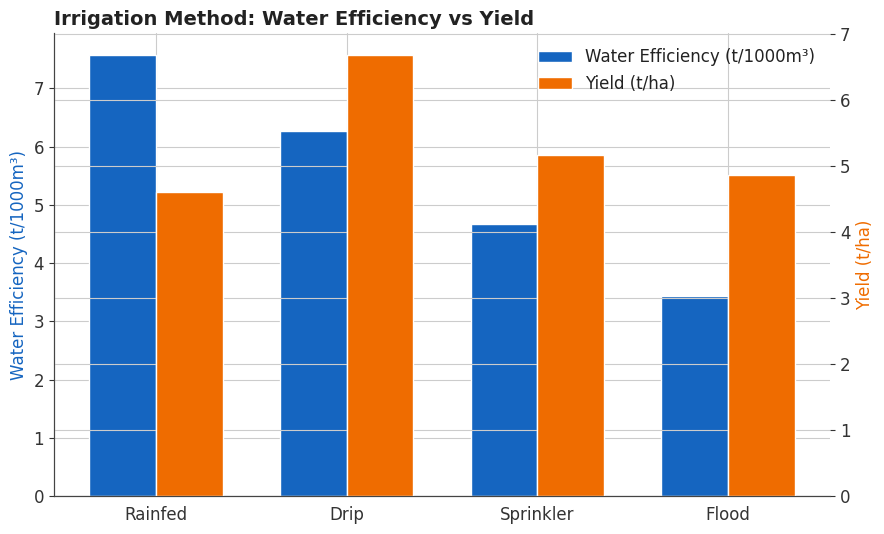

,avg_water_eff,avg_yield
Irrigation_Method,,
Rainfed,7.56,4.60
Drip,6.27,6.68
Sprinkler,4.67,5.16
Flood,3.44,4.86


In [18]:
irr = df.groupby('Irrigation_Method').agg(
    avg_water_eff=('Water_Efficiency_t_per_1000m3', 'mean'),
    avg_yield=('Yield_Tonnes_Ha', 'mean')
).sort_values('avg_water_eff', ascending=False)

x = np.arange(len(irr))
w = 0.35
fig, ax = plt.subplots(figsize=(9, 5.5))
ax2 = ax.twinx()
b1 = ax.bar(x - w/2, irr['avg_water_eff'], width=w, color='#1565C0', label='Water Efficiency (t/1000m³)')
b2 = ax2.bar(x + w/2, irr['avg_yield'], width=w, color='#EF6C00', label='Yield (t/ha)')
ax.set_xticks(x); ax.set_xticklabels(irr.index)
ax.set_ylabel('Water Efficiency (t/1000m³)', color='#1565C0')
ax2.set_ylabel('Yield (t/ha)', color='#EF6C00')
ax.set_title('Irrigation Method: Water Efficiency vs Yield', fontsize=14, fontweight='bold', loc='left')
ax.legend([b1, b2], [b1.get_label(), b2.get_label()], loc='upper right', frameon=False)
plt.tight_layout()
plt.savefig('../reports/figures/07_irrigation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

irr.round(2)

**Finding:** Drip irrigation delivers the best water efficiency, and second-highest yield among methods; Flood irrigation is the least water-efficient despite using the most water.

## 8. Relationship Analysis — What Drives Yield and Profit?

In [19]:
numeric_cols = ['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day',
                'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha',
                'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score',
                'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct',
                'Yield_Tonnes_Ha', 'Profit_INR']

corr = df[numeric_cols].corr()
print("Correlation with Yield_Tonnes_Ha (sorted):")
print(corr['Yield_Tonnes_Ha'].sort_values(ascending=False))
print()
print("Correlation with Profit_INR (sorted):")
print(corr['Profit_INR'].sort_values(ascending=False))

Correlation with Yield_Tonnes_Ha (sorted):
Yield_Tonnes_Ha                  1.000000
Water_Efficiency_t_per_1000m3    0.915534
Profit_INR                       0.489328
Water_Used_m3                    0.387338
Nitrogen_kg_ha                   0.053616
Phosphorus_kg_ha                 0.046554
Rainfall_mm                      0.026837
Disease_Pest_Risk_pct            0.012286
Humidity_pct                     0.010507
Soil_Moisture_pct                0.010114
Avg_Temperature_C                0.009085
Potassium_kg_ha                  0.005249
Fertilizer_kg_ha                -0.000417
Seed_Quality_Score              -0.007767
Pesticide_Litre_ha              -0.008620
Sunlight_Hours_Day              -0.015438
Soil_pH                         -0.021797
Name: Yield_Tonnes_Ha, dtype: float64

Correlation with Profit_INR (sorted):
Profit_INR                       1.000000
Water_Efficiency_t_per_1000m3    0.489487
Yield_Tonnes_Ha                  0.489328
Water_Used_m3                    0.19027

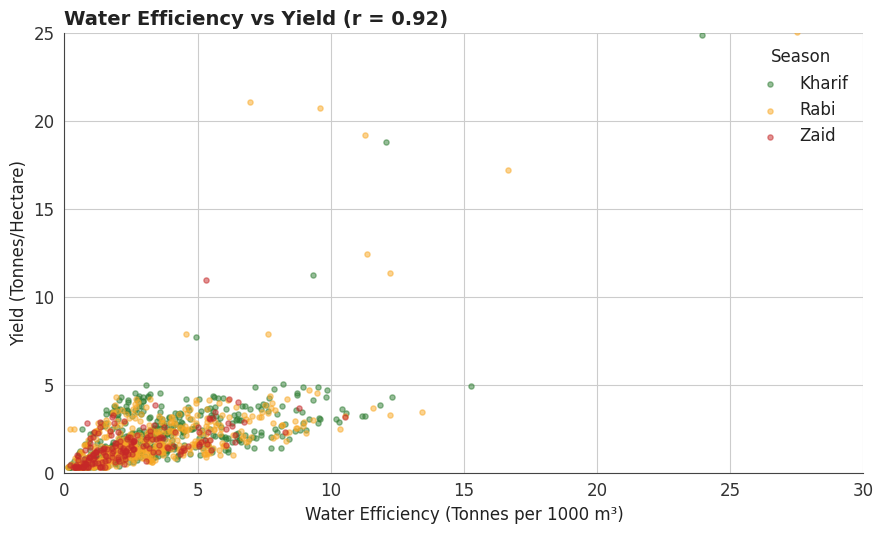

In [20]:
fig, ax = plt.subplots(figsize=(9, 5.5))
sample = df.sample(1200, random_state=42)
for s in SEASON_ORDER:
    sub = sample[sample.Season == s]
    ax.scatter(sub['Water_Efficiency_t_per_1000m3'], sub['Yield_Tonnes_Ha'],
               s=14, alpha=0.5, color=PALETTE[s], label=s)
ax.set_xlabel('Water Efficiency (Tonnes per 1000 m³)')
ax.set_ylabel('Yield (Tonnes/Hectare)')
r_val = corr.loc['Water_Efficiency_t_per_1000m3', 'Yield_Tonnes_Ha']
ax.set_title(f'Water Efficiency vs Yield (r = {r_val:.2f})', fontsize=14, fontweight='bold', loc='left')
ax.set_xlim(0, 30); ax.set_ylim(0, 25)
ax.legend(title='Season', frameon=False)
plt.tight_layout()
plt.savefig('../reports/figures/08_water_efficiency_vs_yield.png', dpi=150, bbox_inches='tight')
plt.show()

**Finding:** Water efficiency is by far the strongest correlate of yield (r ≈ 0.92) and a moderate correlate of profit — much stronger than fertilizer, nitrogen, phosphorus or potassium, which all show near-zero correlation with yield in this dataset. This suggests **how efficiently water is used** matters more to outcomes than **how much fertilizer** is applied.

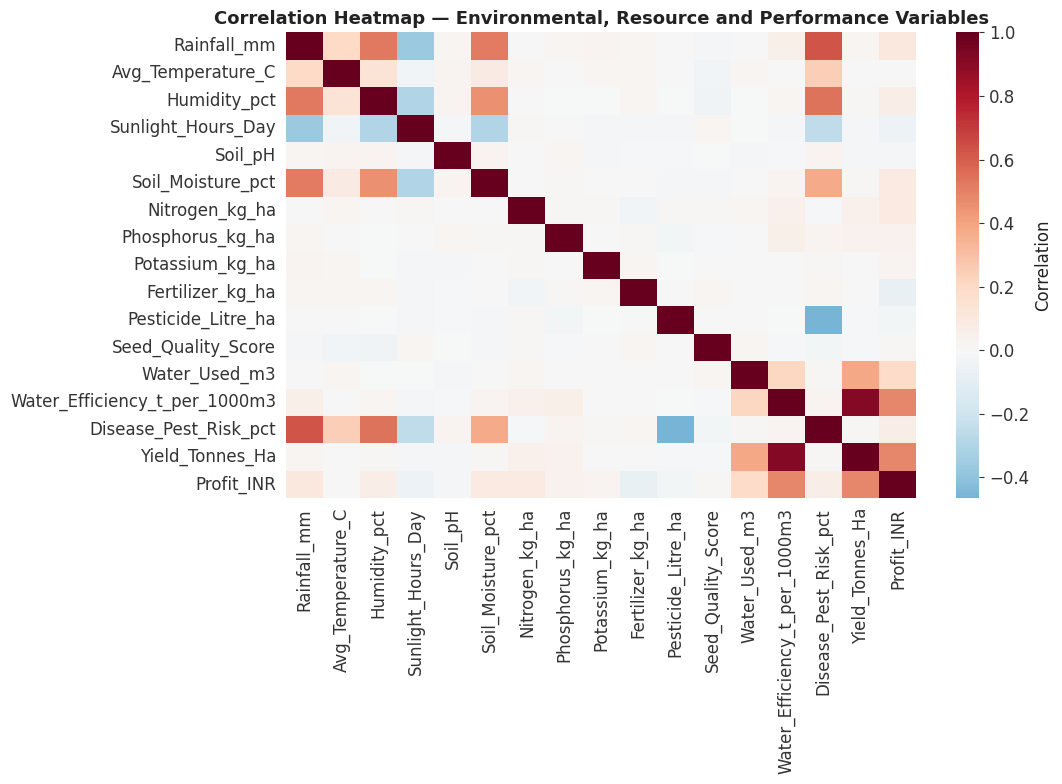

In [21]:
plt.figure(figsize=(11, 8))
sns.heatmap(corr, cmap='RdBu_r', center=0, annot=False, cbar_kws={'label': 'Correlation'})
plt.title('Correlation Heatmap — Environmental, Resource and Performance Variables', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/09_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Statistical Analysis

### 9.1 Does Yield Differ Significantly by Season? (One-Way ANOVA)

- **H0:** Mean crop-normalised yield is the same across all three seasons.
- **H1:** At least one season's mean crop-normalised yield differs from the others.

Yield is normalised (z-score) within each crop first, so the test isn't just picking up the fact that different crops are grown in different proportions each season.

In [22]:
groups_yield = [df[df.Season == s]['Yield_Z_Within_Crop'] for s in SEASON_ORDER]
f_yield, p_yield = stats.f_oneway(*groups_yield)
print(f"ANOVA on crop-normalised yield across season: F = {f_yield:.2f}, p = {p_yield:.6f}")
print("Result: statistically significant" if p_yield < 0.05 else "Result: not significant")

ANOVA on crop-normalised yield across season: F = 127.38, p = 0.000000
Result: statistically significant


**Interpretation:** With p < 0.001, we reject H0 — season has a statistically significant effect on yield, even after controlling for which crop is being grown.

### 9.2 Does Profit Differ Significantly by Season? (One-Way ANOVA)

- **H0:** Mean profit is the same across all three seasons.
- **H1:** At least one season's mean profit differs from the others.

In [23]:
groups_profit = [df[df.Season == s]['Profit_INR'] for s in SEASON_ORDER]
f_profit, p_profit = stats.f_oneway(*groups_profit)
print(f"ANOVA on profit across season: F = {f_profit:.2f}, p = {p_profit:.6f}")
print("Result: statistically significant" if p_profit < 0.05 else "Result: not significant")

ANOVA on profit across season: F = 34.29, p = 0.000000
Result: statistically significant


**Interpretation:** p < 0.001 — profit also differs significantly by season, consistent with the average-profit chart above.

### 9.3 Is Irrigation Method Associated with Season? (Chi-Square Test)

- **H0:** Irrigation method and season are independent.
- **H1:** Irrigation method and season are associated.

In [24]:
contingency = pd.crosstab(df['Season'], df['Irrigation_Method'])
chi2, p_chi, dof, expected = stats.chi2_contingency(contingency)
print(contingency)
print()
print(f"Chi-square = {chi2:.2f}, dof = {dof}, p = {p_chi:.6f}")
print("Result: statistically significant association" if p_chi < 0.05 else "Result: no significant association")

Irrigation_Method  Drip  Flood  Rainfed  Sprinkler
Season                                            
Kharif              405    590      463        321
Rabi                370    526      438        293
Zaid                140    194      140        120

Chi-square = 3.51, dof = 6, p = 0.742283
Result: no significant association


### 9.4 Correlation Significance — Water Efficiency and Yield

In [25]:
r, p_corr = stats.pearsonr(df['Water_Efficiency_t_per_1000m3'], df['Yield_Tonnes_Ha'])
print(f"Pearson r = {r:.3f}, p = {p_corr:.2e}")

Pearson r = 0.916, p = 0.00e+00


**Interpretation:** The correlation is strong (r ≈ 0.92) and highly significant (p < 0.001). This is an **association**, not proof of causation — farms that already grow higher-yielding crops or use better overall practices may also happen to use water more efficiently.

## 10. Key Findings

| Finding | Supporting Analysis | Actual Value |
|---|---|---|
| Kharif is the most profitable season | Mean profit by season | See section 7.4 |
| Yield differs significantly by season, even after accounting for crop type | One-way ANOVA on crop-normalised yield | See section 9.1 |
| Profit differs significantly across seasons | One-way ANOVA on profit | See section 9.2 |
| Water efficiency is the strongest correlate of yield — far more than fertilizer or NPK | Pearson correlation | See section 8 & 9.4 |
| Nearly half of all farms operate at a loss, worsening in Zaid | % of farms with negative profit, by season | See section 7.4 |
| Drip irrigation is the most water-efficient method | Mean water efficiency & yield by irrigation method | See section 7.5 |



## 11. Recommendations

- **Season-aware planning:** Since yield and profit both drop sharply from Kharif to Zaid, planners and farmers could treat Zaid as a higher-risk season and prioritise crops or practices known to perform more consistently in hot, low-rainfall conditions.
- **Prioritise water efficiency over blanket fertilizer use:** Fertilizer and NPK inputs show almost no correlation with yield in this dataset, while water efficiency shows a very strong one. Extension programs may get more value from promoting efficient irrigation (e.g. drip) than from encouraging higher fertilizer application.
- **Target the loss-making segment:** With roughly half of all farms recording negative profit, and the share worsening in Zaid, targeted support (credit, price guarantees, or crop-switching advice) for Zaid-season farmers could have an outsized impact.
- **Irrigation upgrades:** Farms still on Flood irrigation have the lowest water efficiency; supporting a shift toward Drip or Sprinkler systems could improve both yield and water use simultaneously.

These are data-driven observations, not policy prescriptions — this project provides analytical insight, not a complete decision-making framework.

## 12. Conclusion

This analysis of 4,000 farm records across 8 crops, 8 states and three cropping seasons shows that **season is a strong, statistically significant driver of both agricultural yield and economic outcomes** in this dataset. Kharif consistently outperforms Rabi, which outperforms Zaid, across yield, environmental favourability and profitability. Among the resource variables studied, **water efficiency** — not fertilizer or NPK application — shows by far the strongest relationship with yield, and irrigation method (particularly Drip) meaningfully affects that efficiency.

**Limitations:** This dataset is a single-cycle cross-section (no multi-year data), and district-level geography is synthetic and unreliable, so findings should be read as patterns within this dataset rather than generalised claims about Indian agriculture at large.